# 08. Targeted Maximum Likelihood Estimation

The previous notebook introduced AIPW as a doubly robust estimator: start with an outcome model, add inverse-propensity weighted residual corrections, and average the resulting score.

Targeted maximum likelihood estimation, usually abbreviated **TMLE**, uses the same efficient-influence-function logic but organizes it differently. Instead of writing the final estimator as a plug-in term plus residual correction, TMLE starts with an initial outcome model and then performs a **targeting update**. The update nudges the initial outcome predictions in exactly the direction needed for the target parameter.

The short version is:

> TMLE starts with prediction, then targets that prediction toward the causal estimand.

That phrase is worth sitting with. In industry projects, we often have excellent predictive systems but still need a valid causal estimate. TMLE is one principled way to connect prediction, treatment assignment, and causal targeting.

## Learning Goals

By the end of this notebook, you should be able to:

1. Explain the difference between an initial outcome model and a targeted outcome model.
2. Define the clever covariate for the ATE under a binary treatment.
3. Implement a one-step TMLE for a binary outcome and risk-difference estimand.
4. Show that TMLE solves the empirical efficient-influence-curve equation.
5. Compare plug-in outcome regression, IPW, AIPW, and TMLE under nuisance model misspecification.
6. Explain why TMLE is a substitution estimator and why that matters for bounded outcomes.
7. Use cross-fitted machine learning nuisance predictions in a TMLE-style workflow.
8. Communicate TMLE results without overselling the method.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.special import expit, logit
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 3)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz DAG with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="11",
        margin="0.12,0.08",
        color="#334155",
    )
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def clip_prob(p, eps=1e-4):
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)


def standardized_mean_difference(x, d, weights=None):
    x = np.asarray(x, dtype=float)
    d = np.asarray(d, dtype=int) == 1
    if weights is None:
        weights = np.ones(len(x))
    weights = np.asarray(weights, dtype=float)
    mt = weighted_mean(x[d], weights[d])
    mc = weighted_mean(x[~d], weights[~d])
    vt = weighted_mean((x[d] - mt) ** 2, weights[d])
    vc = weighted_mean((x[~d] - mc) ** 2, weights[~d])
    pooled = np.sqrt((vt + vc) / 2)
    return np.nan if pooled == 0 else (mt - mc) / pooled


def balance_table(frame, covariates, weights=None):
    rows = []
    for covariate in covariates:
        smd = standardized_mean_difference(frame[covariate], frame["treated"], weights=weights)
        rows.append({"covariate": covariate, "smd": smd, "abs_smd": abs(smd)})
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def plot_love(balance_tables, title, threshold=0.10, figsize=None):
    plot_df = pd.concat(
        [table.assign(design=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    if figsize is None:
        figsize = (9, max(4.5, 0.38 * len(order)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=plot_df, x="smd", y="covariate", hue="design", style="design", s=80, ax=ax, zorder=3)
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()

## 1. From AIPW to TMLE

AIPW and TMLE are close relatives. Both use:

- an outcome regression $Q(A,W) = E[Y \mid A,W]$;
- a treatment mechanism $g(W) = P(A=1 \mid W)$;
- the efficient influence curve for the target parameter.

The difference is how the final estimate is constructed.

AIPW writes the estimate as an average of an influence-function score:

$$
\hat Q(1,W_i) - \hat Q(0,W_i)
+ \frac{A_i\{Y_i - \hat Q(1,W_i)\}}{\hat g(W_i)}
- \frac{(1-A_i)\{Y_i - \hat Q(0,W_i)\}}{1-\hat g(W_i)}.
$$

TMLE instead updates the initial outcome model to $\hat Q^*$ and then plugs it into the target parameter:

$$
\widehat{ATE}_{TMLE} = \frac{1}{n}\sum_{i=1}^{n}\{\hat Q^*(1,W_i) - \hat Q^*(0,W_i)\}.
$$

This is why TMLE is called a **substitution estimator**: the final estimate is the target parameter evaluated at an updated estimate of the relevant data-generating distribution.

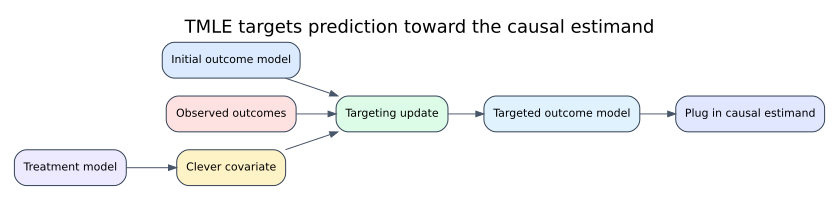

In [3]:
tmle_edges = [
    ("Initial outcome model", "Targeting update"),
    ("Treatment model", "Clever covariate"),
    ("Clever covariate", "Targeting update"),
    ("Observed outcomes", "Targeting update"),
    ("Targeting update", "Targeted outcome model"),
    ("Targeted outcome model", "Plug in causal estimand"),
]

make_dag(
    tmle_edges,
    title="TMLE targets prediction toward the causal estimand",
    node_colors={
        "Initial outcome model": "#dbeafe",
        "Treatment model": "#ede9fe",
        "Clever covariate": "#fef3c7",
        "Observed outcomes": "#fee2e2",
        "Targeting update": "#dcfce7",
        "Targeted outcome model": "#e0f2fe",
        "Plug in causal estimand": "#e0e7ff",
    },
)

### Interpretation

The phrase "targeted maximum likelihood" can sound abstract. In the simple binary-treatment case, the targeting step is just a small regression update. The update uses the treatment model to decide how residuals should influence the outcome predictions.

Van der Laan and Rubin (2006) introduced TMLE as a general framework for targeted learning. Schuler and Rose (2016) present TMLE as a practical alternative for causal inference in observational studies. Gruber and van der Laan (2010) emphasize an important practical point for bounded outcomes: TMLE can respect global constraints because the final estimator is a plug-in estimator.

## 2. The Target Parameter and Efficient Influence Curve

In this notebook we use a binary treatment $A$, covariates $W$, and a binary outcome $Y$. The causal target is the average treatment effect on the risk scale:

$$
\psi = E[Y(1) - Y(0)].
$$

Under consistency, conditional exchangeability, and positivity, this equals the statistical parameter:

$$
\psi = E\{Q(1,W) - Q(0,W)\}.
$$

For this target, the efficient influence curve has the form:

$$
D^*(O) = H(A,W)\{Y - Q(A,W)\} + Q(1,W) - Q(0,W) - \psi,
$$

where the clever covariate is:

$$
H(A,W) = \frac{A}{g(W)} - \frac{1-A}{1-g(W)}.
$$

TMLE updates $Q$ so that the empirical mean of this influence curve is approximately zero:

$$
P_n D^*(\hat Q^*, \hat g, \hat \psi) \approx 0.
$$

## 3. The One-Step Logistic Fluctuation

For a binary outcome, the targeting update is usually written as a logistic fluctuation:

$$
\text{logit}\{\hat Q_{\epsilon}(A,W)\}
= \text{logit}\{\hat Q(A,W)\} + \epsilon H(A,W).
$$

We estimate $\epsilon$ by fitting a logistic regression of $Y$ on $H(A,W)$ with the initial logit prediction as an offset. There is no intercept. The only free coefficient is $\epsilon$.

After estimating $\hat \epsilon$, update the counterfactual predictions:

$$
\text{logit}\{\hat Q^*(1,W)\}
= \text{logit}\{\hat Q(1,W)\} + \frac{\hat \epsilon}{\hat g(W)},
$$

$$
\text{logit}\{\hat Q^*(0,W)\}
= \text{logit}\{\hat Q(0,W)\} - \frac{\hat \epsilon}{1-\hat g(W)}.
$$

Then estimate the risk difference by averaging $\hat Q^*(1,W)-\hat Q^*(0,W)$.

## 4. Running Example: Renewal Retention

We will simulate a SaaS retention setting. The treatment is proactive renewal outreach. The outcome is whether the account renews.

The company targets outreach using churn risk, segment, contract value, engagement, and support capacity. Renewal probability is nonlinear in engagement and risk. Outreach has a heterogeneous effect on renewal probability.

This setting is useful because it resembles a real observational product or customer-success analysis: treatment is targeted, outcomes are bounded, and both prediction and causal estimation matter.

In [4]:
def simulate_retention_outreach(n=8000, seed=8080, targeting_strength=1.0):
    rng = np.random.default_rng(seed)

    segment = rng.choice(["starter", "growth", "enterprise"], p=[0.43, 0.37, 0.20], size=n)
    segment_score = pd.Series(segment).map({"starter": 0.0, "growth": 1.0, "enterprise": 2.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.1, scale=8.0, size=n), 1, 60)
    engagement = np.clip(rng.normal(43 + 4.5 * segment_score + 0.32 * tenure, 13, n), 2, 100)
    contract_value = np.clip(
        rng.lognormal(3.7 + 0.25 * segment_score + 0.005 * engagement, 0.55, n),
        20,
        650,
    )
    support_capacity = rng.normal(0, 1, n)

    risk_score = expit(
        1.35
        - 0.050 * engagement
        - 0.0045 * contract_value
        + 0.012 * tenure
        - 0.42 * segment_score
        + rng.normal(0, 0.75, n)
    )

    assignment_signal = (
        2.30 * risk_score
        + 0.52 * (segment == "enterprise")
        + 0.26 * (segment == "growth")
        + 0.0038 * contract_value
        - 0.018 * engagement
        + 0.70 * support_capacity
        + 1.10 * risk_score * (segment == "enterprise")
    )
    true_propensity = expit(-0.75 + targeting_strength * assignment_signal)
    treated = rng.binomial(1, true_propensity)

    logit_y0 = (
        -0.55
        + 0.030 * engagement
        + 0.006 * contract_value
        + 0.020 * tenure
        + 0.30 * segment_score
        - 2.40 * risk_score
        + 0.85 * risk_score**2
        + 0.45 * np.sin(engagement / 18)
        + 0.42 * risk_score * (segment == "enterprise")
    )

    treatment_log_odds_shift = (
        0.32
        + 0.16 * (segment == "growth")
        + 0.34 * (segment == "enterprise")
        + 0.0045 * engagement
        - 0.55 * risk_score
        + 0.0008 * contract_value
    )

    p0 = expit(logit_y0)
    p1 = expit(logit_y0 + treatment_log_odds_shift)
    observed_probability = np.where(treated == 1, p1, p0)
    outcome = rng.binomial(1, observed_probability)

    return pd.DataFrame({
        "segment": segment,
        "tenure": tenure,
        "engagement": engagement,
        "contract_value": contract_value,
        "support_capacity": support_capacity,
        "risk_score": risk_score,
        "true_propensity": true_propensity,
        "treated": treated,
        "outcome": outcome,
        "p0": p0,
        "p1": p1,
        "true_individual_effect": p1 - p0,
    })


df = simulate_retention_outreach()
true_ate = df["true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "Observed renewal rate",
        "True risk-difference ATE",
        "Naive treated-control difference",
        "Naive bias vs true ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        df["outcome"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

display(summary)
display(df.head())

,quantity,value
0,Number of accounts,8000.000
1,Share receiving outreach,0.363
2,Observed renewal rate,0.840
3,True risk-difference ATE,0.058
4,Naive treated-control difference,0.027
5,Naive bias vs true ATE,-0.031


,segment,tenure,engagement,contract_value,support_capacity,risk_score,true_propensity,treated,outcome,p0,p1,true_individual_effect
0,starter,11.494,30.523,21.926,-1.474,0.680,0.335,1,1,0.484,0.509,0.025
1,growth,2.887,46.436,53.014,0.504,0.192,0.418,1,1,0.791,0.876,0.085
2,growth,6.601,72.268,68.403,-0.412,0.025,0.146,0,0,0.887,0.948,0.061
3,growth,21.549,47.392,92.292,-0.229,0.104,0.286,0,1,0.894,0.945,0.051
4,enterprise,21.153,53.567,94.304,0.608,0.269,0.623,1,1,0.905,0.956,0.051


### Interpretation

The true ATE is a risk difference: the average change in renewal probability if every account received outreach versus if no account received outreach.

The naive treated-control difference is biased because outreach is targeted. Treated accounts are not a random subset of accounts; they are selected by a business process.

## 5. Initial Diagnostics

Before fitting TMLE, inspect treatment overlap and raw covariate balance. The targeting update is not a substitute for design diagnostics.

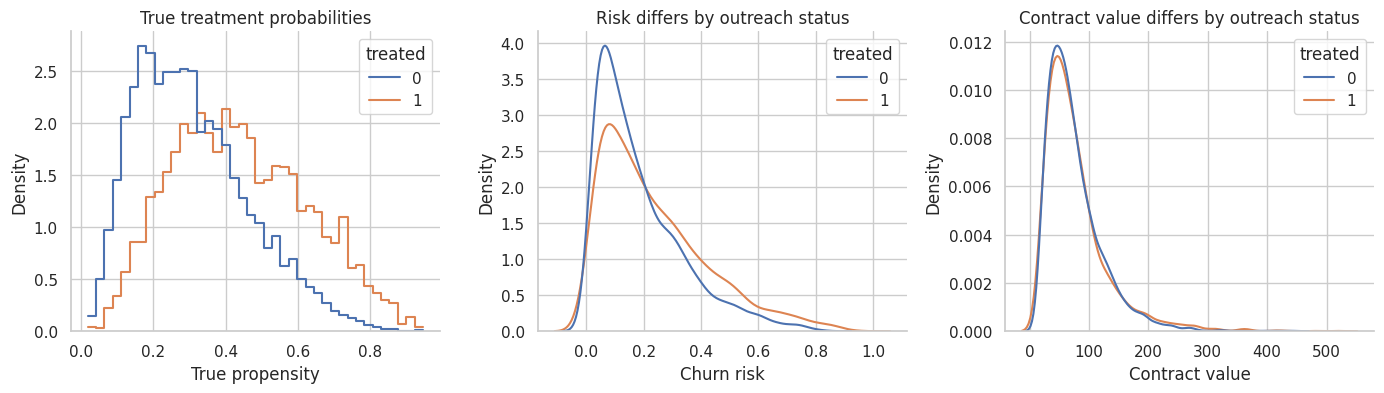

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))

sns.histplot(data=df, x="true_propensity", hue="treated", bins=40, stat="density", common_norm=False, element="step", fill=False, ax=axes[0])
axes[0].set_title("True treatment probabilities")
axes[0].set_xlabel("True propensity")

sns.kdeplot(data=df, x="risk_score", hue="treated", common_norm=False, fill=False, ax=axes[1])
axes[1].set_title("Risk differs by outreach status")
axes[1].set_xlabel("Churn risk")

sns.kdeplot(data=df, x="contract_value", hue="treated", common_norm=False, fill=False, ax=axes[2])
axes[2].set_title("Contract value differs by outreach status")
axes[2].set_xlabel("Contract value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [6]:
segment_dummies = pd.get_dummies(df["segment"], prefix="segment", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "engagement", "contract_value", "tenure", "support_capacity"]], segment_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]
raw_balance = balance_table(balance_frame, balance_covariates)

display(raw_balance)

,covariate,smd,abs_smd
4,support_capacity,0.620,0.620
1,engagement,-0.324,0.324
0,risk_score,0.304,0.304
5,segment_enterprise,0.054,0.054
3,tenure,-0.053,0.053
2,contract_value,0.053,0.053
6,segment_growth,-0.047,0.047
7,segment_starter,0.002,0.002


### Interpretation

The outreach and no-outreach groups differ on several pre-treatment variables. This motivates adjustment. It also reminds us that the causal claim rests on measured covariates being sufficient to control confounding.

## 6. Nuisance Models and Estimator Functions

We will estimate two nuisance functions:

$$
\hat g(W) = \widehat{P}(A=1 \mid W),
$$

and

$$
\hat Q(A,W) = \widehat{E}(Y \mid A,W).
$$

For pedagogy, we will create rich and sparse versions of each model. The rich models include the important structure used in the simulation. The sparse models intentionally omit key confounders.

In [7]:
ps_formula_rich = "treated ~ risk_score + I(risk_score ** 2) + engagement + contract_value + tenure + support_capacity + C(segment) + risk_score:C(segment)"
ps_formula_sparse = "treated ~ support_capacity"

q_formula_rich = "outcome ~ risk_score + I(risk_score ** 2) + engagement + np.sin(engagement / 18) + contract_value + tenure + C(segment) + risk_score:C(segment)"
q_formula_sparse = "outcome ~ C(segment)"


def fit_propensity_formula(frame, formula):
    model = smf.glm(formula, data=frame, family=sm.families.Binomial()).fit(maxiter=100)
    return clip_prob(model.predict(frame)), model


def fit_outcome_formula(frame, formula):
    control_model = smf.glm(formula, data=frame.loc[frame["treated"] == 0], family=sm.families.Binomial()).fit(maxiter=100)
    treated_model = smf.glm(formula, data=frame.loc[frame["treated"] == 1], family=sm.families.Binomial()).fit(maxiter=100)
    q0 = clip_prob(control_model.predict(frame))
    q1 = clip_prob(treated_model.predict(frame))
    return q0, q1, control_model, treated_model


def aipw_scores(frame, g_hat, q0_hat, q1_hat):
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    g_hat = clip_prob(g_hat)
    q0_hat = clip_prob(q0_hat)
    q1_hat = clip_prob(q1_hat)
    return q1_hat - q0_hat + d * (y - q1_hat) / g_hat - (1 - d) * (y - q0_hat) / (1 - g_hat)


def aipw_estimate(frame, g_hat, q0_hat, q1_hat):
    scores = aipw_scores(frame, g_hat, q0_hat, q1_hat)
    estimate = scores.mean()
    se = scores.std(ddof=1) / np.sqrt(len(scores))
    return {"estimate": estimate, "std_error": se, "ci_low": estimate - 1.96 * se, "ci_high": estimate + 1.96 * se}


def ipw_hajek_estimate(frame, g_hat):
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    g_hat = clip_prob(g_hat)
    treated_mean = np.sum(d * y / g_hat) / np.sum(d / g_hat)
    control_mean = np.sum((1 - d) * y / (1 - g_hat)) / np.sum((1 - d) / (1 - g_hat))
    return treated_mean - control_mean


def tmle_binary_ate(frame, g_hat, q0_hat, q1_hat):
    d = frame["treated"].to_numpy(dtype=float)
    y = frame["outcome"].to_numpy(dtype=float)
    g_hat = clip_prob(g_hat)
    q0_hat = clip_prob(q0_hat)
    q1_hat = clip_prob(q1_hat)

    qaw_hat = np.where(d == 1, q1_hat, q0_hat)
    clever_covariate = d / g_hat - (1 - d) / (1 - g_hat)

    fluctuation = sm.GLM(
        y,
        clever_covariate.reshape(-1, 1),
        family=sm.families.Binomial(),
        offset=logit(qaw_hat),
    ).fit()
    epsilon = fluctuation.params[0]

    q1_star = clip_prob(expit(logit(q1_hat) + epsilon / g_hat))
    q0_star = clip_prob(expit(logit(q0_hat) - epsilon / (1 - g_hat)))
    qaw_star = np.where(d == 1, q1_star, q0_star)

    estimate = np.mean(q1_star - q0_star)
    eic = clever_covariate * (y - qaw_star) + q1_star - q0_star - estimate
    se = eic.std(ddof=1) / np.sqrt(len(eic))

    return {
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "epsilon": epsilon,
        "eic_mean": eic.mean(),
        "q0_star": q0_star,
        "q1_star": q1_star,
        "qaw_star": qaw_star,
        "clever_covariate": clever_covariate,
        "eic": eic,
    }

## 7. One TMLE Fit Step by Step

First fit a rich propensity model and a rich outcome model. Then run the targeting step.

In [8]:
g_rich, g_model = fit_propensity_formula(df, ps_formula_rich)
q0_rich, q1_rich, q0_model, q1_model = fit_outcome_formula(df, q_formula_rich)

q_plugin = np.mean(q1_rich - q0_rich)
aipw_rich = aipw_estimate(df, g_rich, q0_rich, q1_rich)
tmle_rich = tmle_binary_ate(df, g_rich, q0_rich, q1_rich)

fit_summary = pd.DataFrame([
    {
        "estimator": "Outcome-regression plug-in",
        "estimate": q_plugin,
        "std_error": np.nan,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "bias_vs_true_ate": q_plugin - true_ate,
    },
    {
        "estimator": "AIPW",
        "estimate": aipw_rich["estimate"],
        "std_error": aipw_rich["std_error"],
        "ci_low": aipw_rich["ci_low"],
        "ci_high": aipw_rich["ci_high"],
        "bias_vs_true_ate": aipw_rich["estimate"] - true_ate,
    },
    {
        "estimator": "TMLE",
        "estimate": tmle_rich["estimate"],
        "std_error": tmle_rich["std_error"],
        "ci_low": tmle_rich["ci_low"],
        "ci_high": tmle_rich["ci_high"],
        "bias_vs_true_ate": tmle_rich["estimate"] - true_ate,
    },
])

display(fit_summary)

targeting_summary = pd.DataFrame({
    "quantity": [
        "Estimated fluctuation epsilon",
        "Mean efficient influence curve after targeting",
        "Propensity model AUC",
        "Min estimated propensity",
        "Max estimated propensity",
    ],
    "value": [
        tmle_rich["epsilon"],
        tmle_rich["eic_mean"],
        roc_auc_score(df["treated"], g_rich),
        g_rich.min(),
        g_rich.max(),
    ],
})

display(targeting_summary)

,estimator,estimate,std_error,ci_low,ci_high,bias_vs_true_ate
0,Outcome-regression plug-in,0.054,NaN,NaN,NaN,-0.004
1,AIPW,0.053,0.009,0.035,0.07,-0.006
2,TMLE,0.053,0.009,0.035,0.07,-0.006


,quantity,value
0,Estimated fluctuation epsilon,-2.429e-03
1,Mean efficient influence curve after targeting,-1.465e-17
2,Propensity model AUC,7.066e-01
3,Min estimated propensity,2.446e-02
4,Max estimated propensity,9.334e-01


### Interpretation

The TMLE and AIPW estimates are close because they are built from the same efficient-influence-function logic and the same nuisance fits. They need not be identical in finite samples.

The targeting step estimated a small fluctuation parameter. Small does not mean unimportant. The point of the targeting step is not to refit the whole outcome model; it is to update the model in the direction that matters for the target parameter.

The empirical mean of the efficient influence curve after targeting is essentially zero. That is the computational signature of the TMLE update.

## 8. Before and After Targeting

The initial outcome model produces $\hat Q(1,W)$ and $\hat Q(0,W)$. TMLE updates these to $\hat Q^*(1,W)$ and $\hat Q^*(0,W)$.

Because we use a logistic fluctuation, all updated predictions remain between zero and one.

,mean,std,min,max
q0_update,5.936e-04,4.799e-04,1.288e-05,7.876e-03
q1_update,-7.749e-04,5.776e-04,-6.592e-03,-1.517e-05
initial_contrast,5.390e-02,3.576e-02,-2.235e-01,2.004e-01
targeted_contrast,5.253e-02,3.552e-02,-2.259e-01,1.963e-01


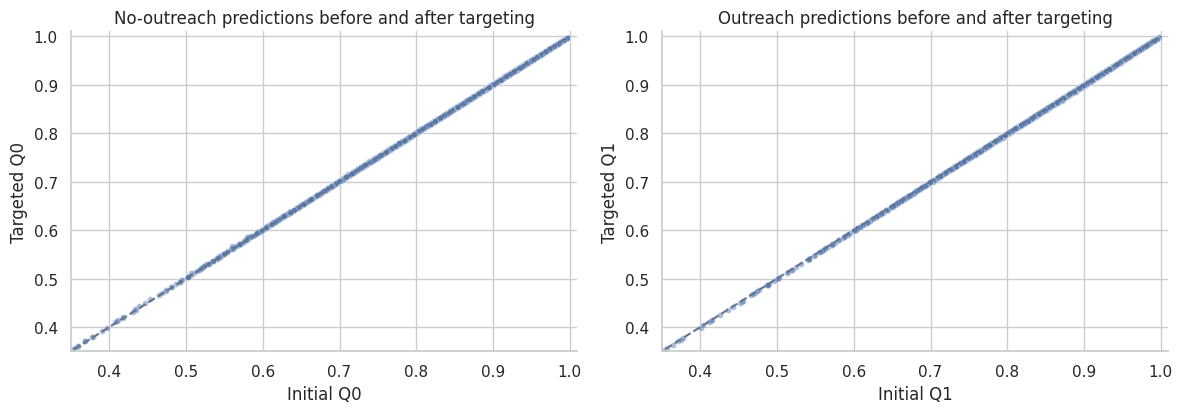

In [9]:
update_frame = pd.DataFrame({
    "q0_initial": q0_rich,
    "q1_initial": q1_rich,
    "q0_targeted": tmle_rich["q0_star"],
    "q1_targeted": tmle_rich["q1_star"],
    "g_hat": g_rich,
    "treated": df["treated"],
    "outcome": df["outcome"],
})
update_frame["q0_update"] = update_frame["q0_targeted"] - update_frame["q0_initial"]
update_frame["q1_update"] = update_frame["q1_targeted"] - update_frame["q1_initial"]
update_frame["initial_contrast"] = update_frame["q1_initial"] - update_frame["q0_initial"]
update_frame["targeted_contrast"] = update_frame["q1_targeted"] - update_frame["q0_targeted"]

update_summary = update_frame[["q0_update", "q1_update", "initial_contrast", "targeted_contrast"]].agg(["mean", "std", "min", "max"]).T

display(update_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

sns.scatterplot(data=update_frame.sample(2500, random_state=8), x="q0_initial", y="q0_targeted", alpha=0.45, s=18, ax=axes[0])
axes[0].plot([0, 1], [0, 1], color="#64748b", linestyle="--")
axes[0].set_title("No-outreach predictions before and after targeting")
axes[0].set_xlabel("Initial Q0")
axes[0].set_ylabel("Targeted Q0")

sns.scatterplot(data=update_frame.sample(2500, random_state=9), x="q1_initial", y="q1_targeted", alpha=0.45, s=18, ax=axes[1])
axes[1].plot([0, 1], [0, 1], color="#64748b", linestyle="--")
axes[1].set_title("Outreach predictions before and after targeting")
axes[1].set_xlabel("Initial Q1")
axes[1].set_ylabel("Targeted Q1")

for ax in axes:
    ax.set_xlim(0.35, 1.01)
    ax.set_ylim(0.35, 1.01)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The targeting step makes a structured, usually small change to the initial predictions. It is not trying to maximize predictive accuracy in the usual supervised-learning sense. It is trying to solve the estimating equation for the causal target.

This is why TMLE is attractive when strong prediction models are available: use them first, then target them.

## 9. Clever Covariates and Influence Values

The clever covariate is large when a unit received a treatment level that was unlikely given its covariates. Those units have more leverage in the targeting update.

This is also why TMLE still needs overlap. If $\hat g(W)$ is very close to zero or one, the clever covariate can be large.

,mean,std,min,max,p01,p99
g_hat,3.631e-01,0.17,0.024,0.933,0.076,0.803
clever_covariate,1.097e-02,2.36,-11.290,28.230,-3.131,6.807
eic,-1.465e-17,0.81,-23.623,6.426,-2.486,1.759


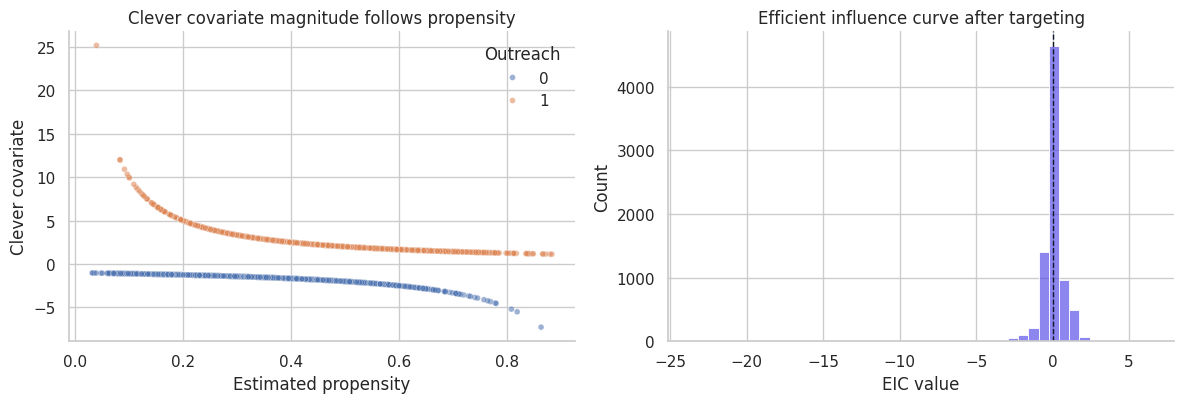

In [10]:
influence_frame = pd.DataFrame({
    "g_hat": g_rich,
    "clever_covariate": tmle_rich["clever_covariate"],
    "eic": tmle_rich["eic"],
    "treated": df["treated"],
})

influence_summary = influence_frame[["g_hat", "clever_covariate", "eic"]].agg(["mean", "std", "min", "max"]).T
influence_summary["p01"] = influence_frame[["g_hat", "clever_covariate", "eic"]].quantile(0.01)
influence_summary["p99"] = influence_frame[["g_hat", "clever_covariate", "eic"]].quantile(0.99)

display(influence_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.scatterplot(data=influence_frame.sample(2500, random_state=10), x="g_hat", y="clever_covariate", hue="treated", alpha=0.55, s=18, ax=axes[0])
axes[0].set_title("Clever covariate magnitude follows propensity")
axes[0].set_xlabel("Estimated propensity")
axes[0].set_ylabel("Clever covariate")
axes[0].legend(title="Outreach", frameon=False)

sns.histplot(influence_frame["eic"], bins=45, color="#4f46e5", alpha=0.65, ax=axes[1])
axes[1].axvline(0, color="#0f172a", linestyle="--", linewidth=1)
axes[1].set_title("Efficient influence curve after targeting")
axes[1].set_xlabel("EIC value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The influence curve is centered near zero after targeting. Its spread determines the standard error. If a few observations have huge clever covariates, the influence curve can become heavy-tailed and the estimate becomes unstable.

This makes TMLE feel less mysterious: it is a targeted prediction update plus an influence-curve based uncertainty calculation.

## 10. TMLE as a Bounded Substitution Estimator

For a binary outcome, $Q^*(1,W)$ and $Q^*(0,W)$ are probabilities. Their individual differences must lie between -1 and 1. The TMLE risk-difference estimate is an average of those probability differences.

AIPW is not a substitution estimator. Its observation-level scores can fall outside the possible range of an individual risk difference because residual corrections are weighted by inverse probabilities.

,quantity,value
0,Min TMLE individual plug-in contrast,-0.226
1,Max TMLE individual plug-in contrast,0.196
2,Min AIPW observation-level score,-23.652
3,Max AIPW observation-level score,6.410
4,TMLE estimate,0.053
5,AIPW estimate,0.053


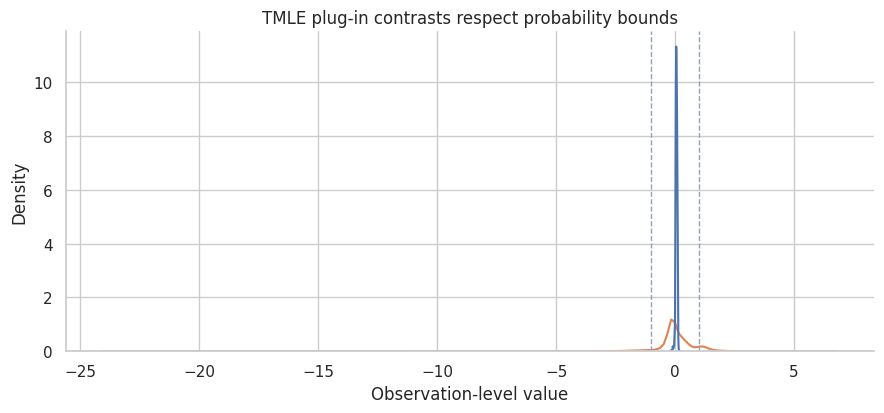

In [11]:
aipw_score_values = aipw_scores(df, g_rich, q0_rich, q1_rich)
substitution_values = tmle_rich["q1_star"] - tmle_rich["q0_star"]

bounds_table = pd.DataFrame({
    "quantity": [
        "Min TMLE individual plug-in contrast",
        "Max TMLE individual plug-in contrast",
        "Min AIPW observation-level score",
        "Max AIPW observation-level score",
        "TMLE estimate",
        "AIPW estimate",
    ],
    "value": [
        substitution_values.min(),
        substitution_values.max(),
        aipw_score_values.min(),
        aipw_score_values.max(),
        tmle_rich["estimate"],
        aipw_rich["estimate"],
    ],
})

display(bounds_table)

fig, ax = plt.subplots(figsize=(9, 4.3))
plot_scores = pd.DataFrame({
    "value": np.concatenate([substitution_values, aipw_score_values]),
    "type": np.repeat(["TMLE plug-in contrasts", "AIPW scores"], len(df)),
})
sns.kdeplot(data=plot_scores, x="value", hue="type", common_norm=False, fill=False, ax=ax)
ax.axvline(-1, color="#94a3b8", linestyle="--", linewidth=1)
ax.axvline(1, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_title("TMLE plug-in contrasts respect probability bounds")
ax.set_xlabel("Observation-level value")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

This distinction matters most when outcomes are binary or otherwise bounded, and when weights are unstable. AIPW can be perfectly valid asymptotically but still produce volatile finite-sample scores. TMLE keeps the final estimate tied to an updated outcome distribution.

## 11. Four Nuisance Specification Scenarios

Like AIPW, TMLE is doubly robust under regularity conditions. It can be consistent if either the outcome regression or the treatment mechanism is consistently estimated.

We will compare four scenarios:

1. Rich $Q$, rich $g$.
2. Rich $Q$, sparse $g$.
3. Sparse $Q$, rich $g$.
4. Sparse $Q$, sparse $g$.

The sparse $g$ model uses only support capacity. The sparse $Q$ model uses only segment. These are intentionally inadequate.

In [12]:
def evaluate_scenario(label, ps_formula, q_formula):
    g_hat, _ = fit_propensity_formula(df, ps_formula)
    q0_hat, q1_hat, _, _ = fit_outcome_formula(df, q_formula)
    tmle = tmle_binary_ate(df, g_hat, q0_hat, q1_hat)
    aipw = aipw_estimate(df, g_hat, q0_hat, q1_hat)
    weights = df["treated"].to_numpy() / clip_prob(g_hat) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(g_hat))
    weighted_balance = balance_table(balance_frame, balance_covariates, weights=weights)
    return {
        "scenario": label,
        "plugin_OR": np.mean(q1_hat - q0_hat),
        "IPW_Hajek": ipw_hajek_estimate(df, g_hat),
        "AIPW": aipw["estimate"],
        "TMLE": tmle["estimate"],
        "TMLE_se": tmle["std_error"],
        "TMLE_epsilon": tmle["epsilon"],
        "TMLE_eic_mean": tmle["eic_mean"],
        "propensity_auc": roc_auc_score(df["treated"], g_hat),
        "ess_share": effective_sample_size(weights) / len(weights),
        "max_weight": weights.max(),
        "max_abs_weighted_smd": weighted_balance["abs_smd"].max(),
    }

scenario_results = pd.DataFrame([
    evaluate_scenario("Rich Q and rich g", ps_formula_rich, q_formula_rich),
    evaluate_scenario("Rich Q and sparse g", ps_formula_sparse, q_formula_rich),
    evaluate_scenario("Sparse Q and rich g", ps_formula_rich, q_formula_sparse),
    evaluate_scenario("Sparse Q and sparse g", ps_formula_sparse, q_formula_sparse),
])

for col in ["plugin_OR", "IPW_Hajek", "AIPW", "TMLE"]:
    scenario_results[f"{col}_bias"] = scenario_results[col] - true_ate

display(scenario_results)

,scenario,plugin_OR,IPW_Hajek,AIPW,TMLE,TMLE_se,TMLE_epsilon,TMLE_eic_mean,propensity_auc,ess_share,max_weight,max_abs_weighted_smd,plugin_OR_bias,IPW_Hajek_bias,AIPW_bias,TMLE_bias
0,Rich Q and rich g,0.054,0.053,0.053,0.053,0.009,-0.002,-1.465e-17,0.707,0.722,28.230,0.019,-0.004,-0.006,-0.006,-0.006
1,Rich Q and sparse g,0.054,0.025,0.053,0.053,0.009,-0.002,5.329e-14,0.670,0.802,12.593,0.351,-0.004,-0.034,-0.006,-0.006
2,Sparse Q and rich g,0.026,0.053,0.053,0.052,0.009,0.040,2.442e-18,0.707,0.722,28.230,0.019,-0.032,-0.006,-0.005,-0.006
3,Sparse Q and sparse g,0.026,0.025,0.022,0.022,0.009,-0.006,3.776e-15,0.670,0.802,12.593,0.351,-0.032,-0.034,-0.036,-0.036


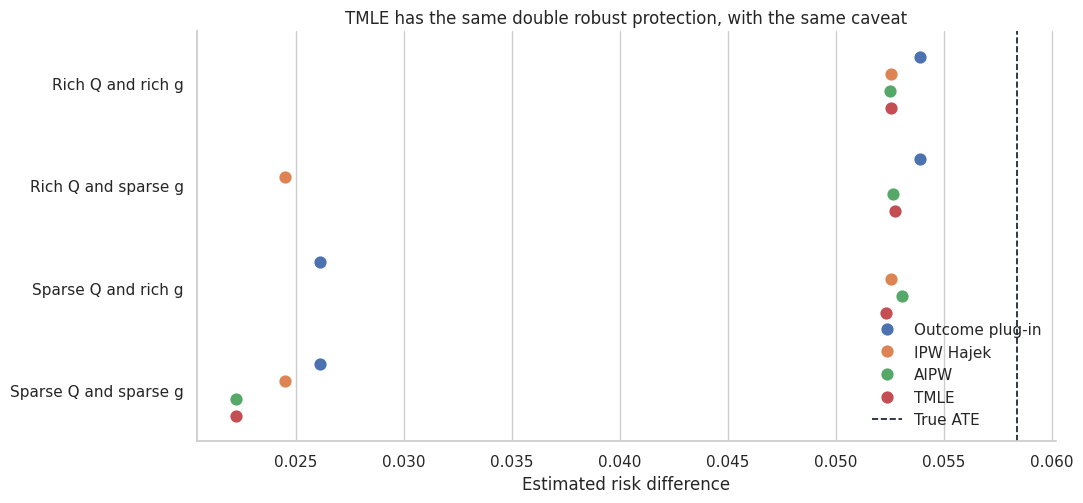

In [13]:
plot_scenarios = scenario_results.melt(
    id_vars="scenario",
    value_vars=["plugin_OR", "IPW_Hajek", "AIPW", "TMLE"],
    var_name="estimator",
    value_name="estimate",
)
plot_scenarios["estimator"] = plot_scenarios["estimator"].map({
    "plugin_OR": "Outcome plug-in",
    "IPW_Hajek": "IPW Hajek",
    "AIPW": "AIPW",
    "TMLE": "TMLE",
})

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.pointplot(data=plot_scenarios, y="scenario", x="estimate", hue="estimator", dodge=0.50, join=False, ax=ax)
ax.axvline(true_ate, color="#0f172a", linestyle="--", linewidth=1.2, label="True ATE")
ax.set_title("TMLE has the same double robust protection, with the same caveat")
ax.set_xlabel("Estimated risk difference")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The rich outcome model protects the estimate even when the propensity model is sparse. The rich propensity model protects the estimate even when the outcome model is sparse. When both models are sparse, TMLE is not protected.

This is the same conceptual warning as AIPW: double robust is not double magic. It gives two routes to consistency, not immunity from poor design or two bad nuisance models.

## 12. Monte Carlo Check

A single dataset can make one estimator look lucky or unlucky. We will repeat the four scenarios across many simulated datasets and examine mean bias and RMSE.

To keep the computation fast, this Monte Carlo uses scikit-learn logistic models for nuisance predictions, followed by the same TMLE targeting function.

In [14]:
def make_feature_matrix(frame, spec):
    out = pd.DataFrame(index=frame.index)
    if spec == "ps_rich":
        out["risk_score"] = frame["risk_score"]
        out["risk_score_sq"] = frame["risk_score"] ** 2
        out["engagement"] = frame["engagement"]
        out["contract_value"] = frame["contract_value"]
        out["tenure"] = frame["tenure"]
        out["support_capacity"] = frame["support_capacity"]
        dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
        out = pd.concat([out, dummies], axis=1)
        out["risk_x_enterprise"] = frame["risk_score"] * (frame["segment"] == "enterprise").astype(float)
    elif spec == "ps_sparse":
        out["support_capacity"] = frame["support_capacity"]
    elif spec == "q_rich":
        out["risk_score"] = frame["risk_score"]
        out["risk_score_sq"] = frame["risk_score"] ** 2
        out["engagement"] = frame["engagement"]
        out["sin_engagement"] = np.sin(frame["engagement"] / 18)
        out["contract_value"] = frame["contract_value"]
        out["tenure"] = frame["tenure"]
        dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
        out = pd.concat([out, dummies], axis=1)
        out["risk_x_enterprise"] = frame["risk_score"] * (frame["segment"] == "enterprise").astype(float)
    elif spec == "q_sparse":
        out = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
    else:
        raise ValueError(f"Unknown feature spec: {spec}")
    return out.astype(float)


def sklearn_nuisance_predictions(frame, ps_spec, q_spec):
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=int)
    x_ps = make_feature_matrix(frame, ps_spec)
    x_q = make_feature_matrix(frame, q_spec)

    ps_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=700, C=1e6))
    ps_model.fit(x_ps, d)
    g_hat = clip_prob(ps_model.predict_proba(x_ps)[:, 1])

    q0_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=700, C=1e6))
    q1_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=700, C=1e6))
    q0_model.fit(x_q.loc[d == 0], y[d == 0])
    q1_model.fit(x_q.loc[d == 1], y[d == 1])
    q0_hat = clip_prob(q0_model.predict_proba(x_q)[:, 1])
    q1_hat = clip_prob(q1_model.predict_proba(x_q)[:, 1])
    return g_hat, q0_hat, q1_hat


def run_mc_once(seed, n=1200, ps_spec="ps_rich", q_spec="q_rich"):
    frame = simulate_retention_outreach(n=n, seed=seed)
    g_hat, q0_hat, q1_hat = sklearn_nuisance_predictions(frame, ps_spec, q_spec)
    truth = frame["true_individual_effect"].mean()
    tmle = tmle_binary_ate(frame, g_hat, q0_hat, q1_hat)
    aipw = aipw_estimate(frame, g_hat, q0_hat, q1_hat)
    return {
        "true_ate": truth,
        "plugin_OR": np.mean(q1_hat - q0_hat),
        "IPW_Hajek": ipw_hajek_estimate(frame, g_hat),
        "AIPW": aipw["estimate"],
        "TMLE": tmle["estimate"],
    }

mc_scenarios = [
    ("Rich Q and rich g", "ps_rich", "q_rich"),
    ("Rich Q and sparse g", "ps_sparse", "q_rich"),
    ("Sparse Q and rich g", "ps_rich", "q_sparse"),
    ("Sparse Q and sparse g", "ps_sparse", "q_sparse"),
]

mc_rows = []
for scenario_id, (scenario, ps_spec, q_spec) in enumerate(mc_scenarios):
    for rep in range(60):
        row = run_mc_once(seed=12000 + 1000 * scenario_id + rep, ps_spec=ps_spec, q_spec=q_spec)
        row["scenario"] = scenario
        row["rep"] = rep
        mc_rows.append(row)

mc = pd.DataFrame(mc_rows)
mc_long = mc.melt(
    id_vars=["scenario", "rep", "true_ate"],
    value_vars=["plugin_OR", "IPW_Hajek", "AIPW", "TMLE"],
    var_name="estimator",
    value_name="estimate",
)
mc_long["error"] = mc_long["estimate"] - mc_long["true_ate"]
mc_long["estimator"] = mc_long["estimator"].map({
    "plugin_OR": "Outcome plug-in",
    "IPW_Hajek": "IPW Hajek",
    "AIPW": "AIPW",
    "TMLE": "TMLE",
})

mc_summary = (
    mc_long.groupby(["scenario", "estimator"])
    .agg(
        mean_estimate=("estimate", "mean"),
        mean_bias=("error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(np.asarray(x) ** 2))),
        error_sd=("error", "std"),
    )
    .reset_index()
)

display(mc_summary)

,scenario,estimator,mean_estimate,mean_bias,rmse,error_sd
0,Rich Q and rich g,AIPW,0.058,-5.702e-04,0.023,0.023
1,Rich Q and rich g,IPW Hajek,0.058,-1.114e-03,0.024,0.024
2,Rich Q and rich g,Outcome plug-in,0.058,-1.165e-03,0.019,0.019
3,Rich Q and rich g,TMLE,0.058,-4.850e-04,0.023,0.023
4,Rich Q and sparse g,AIPW,0.059,5.692e-04,0.021,0.022
5,Rich Q and sparse g,IPW Hajek,0.029,-2.910e-02,0.038,0.025
6,Rich Q and sparse g,Outcome plug-in,0.060,1.327e-03,0.019,0.019
7,Rich Q and sparse g,TMLE,0.059,5.499e-04,0.021,0.022
8,Sparse Q and rich g,AIPW,0.059,3.539e-04,0.025,0.026
9,Sparse Q and rich g,IPW Hajek,0.059,7.127e-04,0.026,0.026


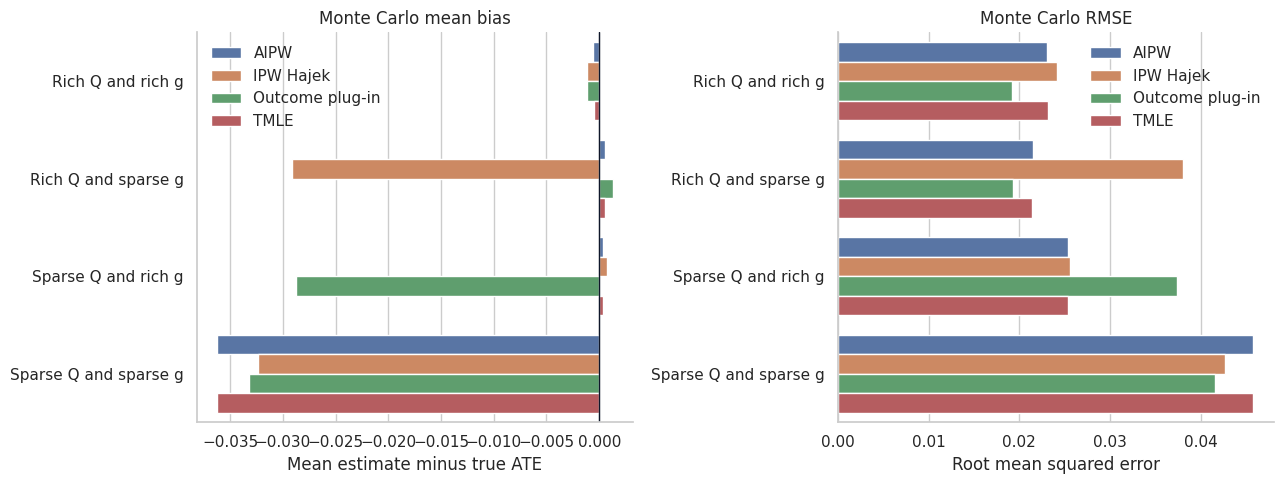

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

sns.barplot(data=mc_summary, y="scenario", x="mean_bias", hue="estimator", ax=axes[0])
axes[0].axvline(0, color="#0f172a", linewidth=1)
axes[0].set_title("Monte Carlo mean bias")
axes[0].set_xlabel("Mean estimate minus true ATE")
axes[0].set_ylabel("")
axes[0].legend(frameon=False)

sns.barplot(data=mc_summary, y="scenario", x="rmse", hue="estimator", ax=axes[1])
axes[1].set_title("Monte Carlo RMSE")
axes[1].set_xlabel("Root mean squared error")
axes[1].set_ylabel("")
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The repeated simulations show the expected pattern. TMLE behaves well when at least one nuisance route is rich. When both nuisance models are intentionally sparse, the doubly robust protection is no longer available.

The Monte Carlo also shows that AIPW and TMLE are often numerically close when built from the same nuisance predictions. The reasons to prefer TMLE are not that it always produces a very different number. The reasons are its substitution-estimator structure, its targeting interpretation, and its compatibility with flexible nuisance learning.

## 13. TMLE Still Needs Overlap

The clever covariate contains inverse propensity terms. Therefore, TMLE can become unstable when estimated propensities are close to zero or one.

We can stress-test this by increasing the targeting strength in the treatment assignment mechanism.

In [16]:
weak_df = simulate_retention_outreach(n=8000, seed=8181, targeting_strength=1.9)
weak_true_ate = weak_df["true_individual_effect"].mean()
weak_g, _ = fit_propensity_formula(weak_df, ps_formula_rich)
weak_q0, weak_q1, _, _ = fit_outcome_formula(weak_df, q_formula_rich)
weak_tmle = tmle_binary_ate(weak_df, weak_g, weak_q0, weak_q1)
weak_weights = weak_df["treated"].to_numpy() / clip_prob(weak_g) + (1 - weak_df["treated"].to_numpy()) / (1 - clip_prob(weak_g))
regular_weights = df["treated"].to_numpy() / clip_prob(g_rich) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(g_rich))

positivity_summary = pd.DataFrame([
    {
        "design": "Moderate targeting",
        "treated_share": df["treated"].mean(),
        "ps_p01": np.quantile(g_rich, 0.01),
        "ps_p99": np.quantile(g_rich, 0.99),
        "max_weight": regular_weights.max(),
        "ess_share": effective_sample_size(regular_weights) / len(regular_weights),
        "TMLE_estimate": tmle_rich["estimate"],
        "TMLE_se": tmle_rich["std_error"],
        "true_ate": true_ate,
    },
    {
        "design": "Aggressive targeting",
        "treated_share": weak_df["treated"].mean(),
        "ps_p01": np.quantile(weak_g, 0.01),
        "ps_p99": np.quantile(weak_g, 0.99),
        "max_weight": weak_weights.max(),
        "ess_share": effective_sample_size(weak_weights) / len(weak_weights),
        "TMLE_estimate": weak_tmle["estimate"],
        "TMLE_se": weak_tmle["std_error"],
        "true_ate": weak_true_ate,
    },
])

display(positivity_summary)

,design,treated_share,ps_p01,ps_p99,max_weight,ess_share,TMLE_estimate,TMLE_se,true_ate
0,Moderate targeting,0.363,0.076,0.803,28.230,0.722,0.053,0.009,0.058
1,Aggressive targeting,0.394,0.013,0.969,57.277,0.438,0.062,0.010,0.059


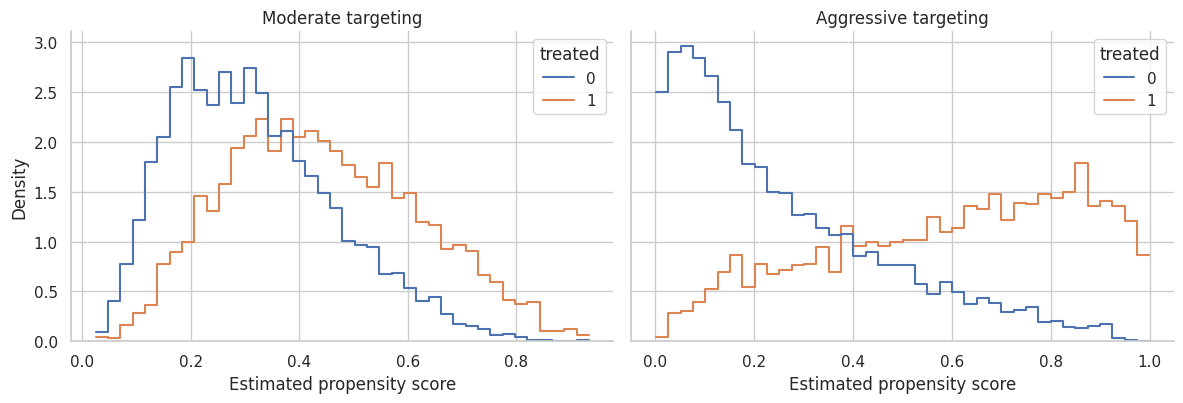

In [17]:
overlap_plot = pd.concat(
    [
        pd.DataFrame({"propensity": g_rich, "treated": df["treated"], "design": "Moderate targeting"}),
        pd.DataFrame({"propensity": weak_g, "treated": weak_df["treated"], "design": "Aggressive targeting"}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, design in zip(axes, ["Moderate targeting", "Aggressive targeting"]):
    sns.histplot(
        data=overlap_plot.loc[overlap_plot["design"] == design],
        x="propensity",
        hue="treated",
        stat="density",
        common_norm=False,
        bins=40,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(design)
    ax.set_xlabel("Estimated propensity score")
    sns.despine(ax=ax)
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

### Interpretation

Under aggressive targeting, estimated propensities move closer to the boundaries. The clever covariate and inverse-propensity weights become more variable. The TMLE standard error increases because the efficient influence curve becomes more variable.

TMLE is robust to certain nuisance-model failures. It is not robust to missing support.

## 14. Cross-Fitted TMLE With Flexible Nuisance Models

TMLE is commonly paired with flexible prediction methods. The Super Learner idea of van der Laan, Polley, and Hubbard (2007) uses cross-validation to combine candidate learners. Cross-validated TMLE variants were developed to make targeted learning work better with adaptive nuisance estimation.

Here we implement a lightweight cross-fitted TMLE pattern:

1. Split accounts into folds.
2. Train nuisance models on training folds.
3. Predict $\hat g$, $\hat Q(0,W)$, and $\hat Q(1,W)$ on held-out folds.
4. Run the targeting step using out-of-fold nuisance predictions.

This is not a full software-grade CV-TMLE implementation, but it captures the workflow logic.

In [18]:
def ml_feature_matrix(frame):
    x = pd.DataFrame(index=frame.index)
    x["risk_score"] = frame["risk_score"]
    x["engagement"] = frame["engagement"]
    x["contract_value"] = frame["contract_value"]
    x["tenure"] = frame["tenure"]
    x["support_capacity"] = frame["support_capacity"]
    x["risk_x_contract"] = frame["risk_score"] * frame["contract_value"]
    x["engagement_sq"] = frame["engagement"] ** 2
    dummies = pd.get_dummies(frame["segment"], prefix="segment", drop_first=True, dtype=float)
    return pd.concat([x, dummies], axis=1).astype(float)


def crossfit_tmle_predictions(frame, n_splits=5, seed=123):
    x = ml_feature_matrix(frame)
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=int)

    g_hat = np.zeros(len(frame))
    q0_hat = np.zeros(len(frame))
    q1_hat = np.zeros(len(frame))

    ps_template = HistGradientBoostingClassifier(max_iter=90, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    q_template = HistGradientBoostingClassifier(max_iter=110, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kfold.split(x):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        d_train = d[train_idx]
        y_train = y[train_idx]

        ps_model = clone(ps_template)
        ps_model.fit(x_train, d_train)
        g_hat[test_idx] = ps_model.predict_proba(x_test)[:, 1]

        q0_model = clone(q_template)
        q1_model = clone(q_template)
        q0_model.fit(x_train.loc[d_train == 0], y_train[d_train == 0])
        q1_model.fit(x_train.loc[d_train == 1], y_train[d_train == 1])
        q0_hat[test_idx] = q0_model.predict_proba(x_test)[:, 1]
        q1_hat[test_idx] = q1_model.predict_proba(x_test)[:, 1]

    return clip_prob(g_hat), clip_prob(q0_hat), clip_prob(q1_hat)


def same_sample_ml_predictions(frame, seed=123):
    x = ml_feature_matrix(frame)
    d = frame["treated"].to_numpy(dtype=int)
    y = frame["outcome"].to_numpy(dtype=int)

    ps_model = HistGradientBoostingClassifier(max_iter=90, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    q0_model = HistGradientBoostingClassifier(max_iter=110, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)
    q1_model = HistGradientBoostingClassifier(max_iter=110, learning_rate=0.055, max_leaf_nodes=18, random_state=seed)

    ps_model.fit(x, d)
    q0_model.fit(x.loc[d == 0], y[d == 0])
    q1_model.fit(x.loc[d == 1], y[d == 1])

    g_hat = clip_prob(ps_model.predict_proba(x)[:, 1])
    q0_hat = clip_prob(q0_model.predict_proba(x)[:, 1])
    q1_hat = clip_prob(q1_model.predict_proba(x)[:, 1])
    return g_hat, q0_hat, q1_hat

same_g, same_q0, same_q1 = same_sample_ml_predictions(df)
cf_g, cf_q0, cf_q1 = crossfit_tmle_predictions(df)

same_tmle = tmle_binary_ate(df, same_g, same_q0, same_q1)
cf_tmle = tmle_binary_ate(df, cf_g, cf_q0, cf_q1)

ml_tmle_results = pd.DataFrame([
    {
        "approach": "Same-sample ML nuisance predictions",
        "plugin_OR": np.mean(same_q1 - same_q0),
        "TMLE": same_tmle["estimate"],
        "TMLE_se": same_tmle["std_error"],
        "propensity_auc": roc_auc_score(df["treated"], same_g),
        "epsilon": same_tmle["epsilon"],
        "true_ate": true_ate,
    },
    {
        "approach": "Cross-fitted ML nuisance predictions",
        "plugin_OR": np.mean(cf_q1 - cf_q0),
        "TMLE": cf_tmle["estimate"],
        "TMLE_se": cf_tmle["std_error"],
        "propensity_auc": roc_auc_score(df["treated"], cf_g),
        "epsilon": cf_tmle["epsilon"],
        "true_ate": true_ate,
    },
])
ml_tmle_results["TMLE_bias_vs_true_ate"] = ml_tmle_results["TMLE"] - true_ate

display(ml_tmle_results)

,approach,plugin_OR,TMLE,TMLE_se,propensity_auc,epsilon,true_ate,TMLE_bias_vs_true_ate
0,Same-sample ML nuisance predictions,0.059,0.059,0.007,0.772,6.855e-04,0.058,6.319e-04
1,Cross-fitted ML nuisance predictions,0.063,0.057,0.009,0.689,-1.172e-02,0.058,-1.531e-03


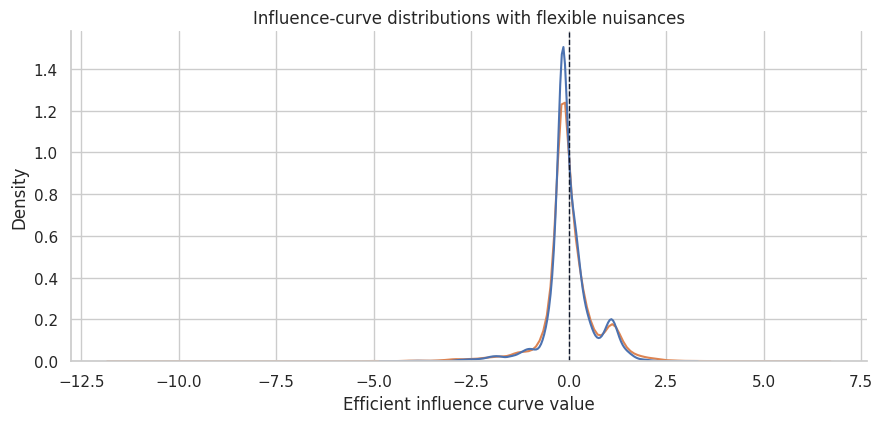

In [19]:
ml_plot = pd.DataFrame({
    "score": np.concatenate([same_tmle["eic"], cf_tmle["eic"]]),
    "approach": np.repeat(["Same-sample", "Cross-fitted"], len(df)),
})

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.kdeplot(data=ml_plot, x="score", hue="approach", common_norm=False, fill=False, ax=ax)
ax.axvline(0, color="#0f172a", linestyle="--", linewidth=1)
ax.set_title("Influence-curve distributions with flexible nuisances")
ax.set_xlabel("Efficient influence curve value")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

Cross-fitting changes the nuisance predictions because every account receives predictions from models that did not train on that account. With flexible learners, this is often preferable for causal estimation.

The point is not that cross-fitting always moves the estimate in a specific direction. The point is that it separates nuisance learning from target-parameter evaluation and reduces overfitting leakage into the causal score.

## 15. A Practical TMLE Reporting Dashboard

A TMLE report should include the estimate, uncertainty, nuisance diagnostics, overlap diagnostics, and sensitivity across nuisance choices.

,diagnostic,value,interpretation
0,TMLE estimate,5.253e-02,Estimated risk-difference ATE
1,TMLE standard error,9.054e-03,Influence-curve based uncertainty
2,Mean EIC after targeting,-1.465e-17,Should be numerically close to zero
3,Propensity AUC,7.066e-01,High values require overlap inspection
4,ATE-weight ESS share,7.219e-01,Lower values indicate less effective information
5,Max weighted absolute SMD,1.900e-02,Balance check for the treatment model route
6,Max absolute EIC,2.362e+01,Influence check for extreme observations


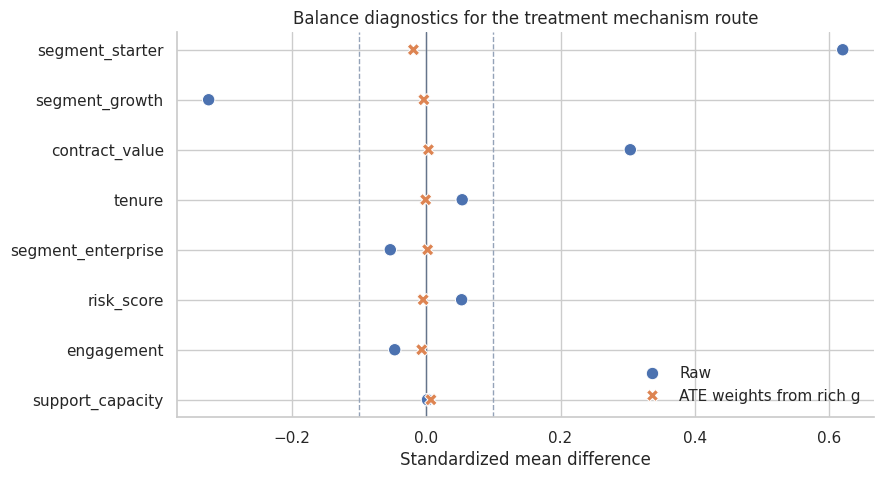

In [20]:
rich_weights = df["treated"].to_numpy() / clip_prob(g_rich) + (1 - df["treated"].to_numpy()) / (1 - clip_prob(g_rich))
weighted_balance = balance_table(balance_frame, balance_covariates, weights=rich_weights)

report_dashboard = pd.DataFrame([
    {
        "diagnostic": "TMLE estimate",
        "value": tmle_rich["estimate"],
        "interpretation": "Estimated risk-difference ATE",
    },
    {
        "diagnostic": "TMLE standard error",
        "value": tmle_rich["std_error"],
        "interpretation": "Influence-curve based uncertainty",
    },
    {
        "diagnostic": "Mean EIC after targeting",
        "value": tmle_rich["eic_mean"],
        "interpretation": "Should be numerically close to zero",
    },
    {
        "diagnostic": "Propensity AUC",
        "value": roc_auc_score(df["treated"], g_rich),
        "interpretation": "High values require overlap inspection",
    },
    {
        "diagnostic": "ATE-weight ESS share",
        "value": effective_sample_size(rich_weights) / len(rich_weights),
        "interpretation": "Lower values indicate less effective information",
    },
    {
        "diagnostic": "Max weighted absolute SMD",
        "value": weighted_balance["abs_smd"].max(),
        "interpretation": "Balance check for the treatment model route",
    },
    {
        "diagnostic": "Max absolute EIC",
        "value": np.max(np.abs(tmle_rich["eic"])),
        "interpretation": "Influence check for extreme observations",
    },
])

display(report_dashboard)
plot_love(
    {
        "Raw": raw_balance,
        "ATE weights from rich g": weighted_balance,
    },
    title="Balance diagnostics for the treatment mechanism route",
    figsize=(9, 5.0),
)

### Interpretation

The dashboard keeps the estimate connected to the design. TMLE is powerful, but the deliverable should still make clear whether the treatment mechanism supports the target population, whether the influence curve is stable, and whether the estimate is sensitive to nuisance choices.

## 16. What to Say in an Industry Readout

A weak readout says:

> We used TMLE, so the estimate is robust and machine-learning based.

A stronger readout says:

> We estimated the effect of proactive outreach on renewal probability using targeted maximum likelihood estimation. The initial outcome model predicted renewal under outreach and no outreach. The targeting update used the estimated outreach propensity to adjust those predictions toward the causal risk-difference target. The final estimate is a plug-in risk difference based on the targeted outcome model. We report influence-curve uncertainty, propensity-score overlap, weight stability, covariate balance, and sensitivity across nuisance specifications. The result should be interpreted under the measured-confounding and positivity assumptions.

That version makes the method credible because it names both the estimator and the assumptions.

## 17. Common Mistakes

1. **Treating TMLE as a black-box package call**: the initial $Q$, treatment model $g$, clever covariate, targeting update, and influence curve should all be understood.
2. **Skipping overlap checks**: the clever covariate contains inverse propensity terms.
3. **Using post-treatment variables**: the nuisance models should use pre-treatment variables for point-treatment causal effects.
4. **Calling it robust without saying to what**: TMLE is doubly robust under assumptions, not assumption-free.
5. **Ignoring boundedness**: for binary or bounded outcomes, the substitution-estimator property is a genuine advantage.
6. **Confusing prediction performance with causal validity**: strong predictive accuracy does not by itself justify exchangeability.

## Key Takeaways

- TMLE starts with an initial outcome model and targets it toward the causal estimand using the treatment mechanism.
- For the binary-treatment ATE, the clever covariate is $A/g(W) - (1-A)/(1-g(W))$.
- The one-step logistic fluctuation updates $Q$ so that the empirical efficient-influence-curve equation is solved.
- TMLE and AIPW are closely related; both are doubly robust under regularity conditions.
- TMLE is a substitution estimator, so for binary outcomes it estimates the risk difference by averaging valid updated probability contrasts.
- TMLE still needs overlap, measured-confounding assumptions, and careful nuisance diagnostics.
- Cross-fitting and Super Learner style nuisance estimation make TMLE especially useful in modern causal ML workflows.

## References

Gruber, S., & van der Laan, M. J. (2010). A targeted maximum likelihood estimator of a causal effect on a bounded continuous outcome. *The International Journal of Biostatistics, 6*(1). https://doi.org/10.2202/1557-4679.1260

Schuler, M. S., & Rose, S. (2016). Targeted maximum likelihood estimation for causal inference in observational studies. *American Journal of Epidemiology, 185*(1), 65-73. https://doi.org/10.1093/aje/kww165

van der Laan, M. J., Polley, E. C., & Hubbard, A. E. (2007). Super Learner. *Statistical Applications in Genetics and Molecular Biology, 6*(1). https://doi.org/10.2202/1544-6115.1309

van der Laan, M. J., & Rubin, D. B. (2006). Targeted maximum likelihood learning. *The International Journal of Biostatistics, 2*(1). https://doi.org/10.2202/1557-4679.1043

Levy, J. I. (2018). An easy implementation of CV-TMLE. *arXiv*. https://doi.org/10.48550/arXiv.1811.04573